# JUDUL : Klasifikasi Tingkat Berat Sampah Laut di Kawasan Pesisir Menggunakan Random Forest (SDG 14: Ekosistem Lautan)
**Tugas:** memprediksi apakah suatu lokasi survei pesisir tergolong sampah **Ringan** atau **Berat**, berdasarkan jumlah item sampah yang ditemukan.

**Dataset:** `Marine Debris-Data-UoP.xlsx` (120 survei pesisir, 41 jenis item sampah)
**Target:** SDG 14 - Life Below Water

**Catatan perubahan dari versi sebelumnya:** awalnya masalah ini dicoba sebagai *regresi* (memprediksi berat dalam kg), tetapi hasilnya lemah (R2 terbaik sekitar 0.09 pada Random Forest). Jumlah item ternyata hanya berkorelasi lemah dengan berat (sekitar 0.37) dan datanya hanya 120 sampel. Karena itu masalah didefinisikan ulang sebagai *klasifikasi* dua kelas, sehingga akurasi bisa dipakai sebagai metrik. Petugas lapangan tetap dapat memakainya untuk memutuskan lokasi mana yang perlu prioritas pengangkutan.

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance

## 2. Load Dataset dan Preprocessing
File Excel tidak punya header di baris pertama, jadi kolom diambil berdasarkan posisi: kolom 8 sampai 48 sebagai fitur (jumlah tiap jenis item), kolom 49 sebagai berat (kg). Baris yang beratnya kosong dibuang, dan item yang kosong diisi 0 (dianggap tidak ditemukan).

In [2]:
df_raw = pd.read_excel("Marine Debris-Data-UoP.xlsx", sheet_name="Dataset", header=None)

X_raw = df_raw.iloc[2:, 8:49].apply(pd.to_numeric, errors='coerce')
berat = df_raw.iloc[2:, 49].apply(pd.to_numeric, errors='coerce')

valid = berat.dropna().index
X = X_raw.loc[valid].fillna(0)
berat = berat.loc[valid]
X.columns = [f"Item_{i}" for i in range(1, X.shape[1] + 1)]

print("Jumlah sampel :", X.shape[0])
print("Jumlah fitur  :", X.shape[1])
print(berat.describe().round(2))

Jumlah sampel : 120
Jumlah fitur  : 41
count    120.00
mean       9.45
std        9.06
min        0.00
25%        3.58
50%        7.00
75%       12.00
max       43.00
Name: 49, dtype: float64


## 3. Membuat Label (Ringan / Berat)
Batasnya memakai **median** berat, sehingga kedua kelas kurang lebih seimbang dan SMOTE tidak diperlukan.
- 0 = Ringan (berat <= median)
- 1 = Berat (berat > median)

Batas (median berat): 7.0 kg
49
Ringan    63
Berat     57
Name: count, dtype: int64


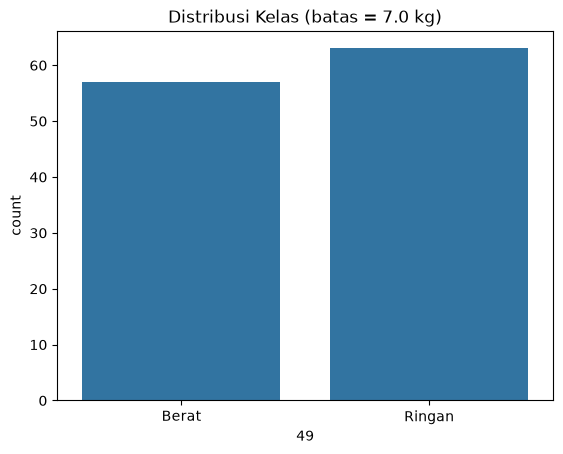

In [3]:
batas = berat.median()
y = (berat > batas).astype(int)

print(f"Batas (median berat): {batas} kg")
print(y.value_counts().rename({0: "Ringan", 1: "Berat"}))

sns.countplot(x=y.map({0: "Ringan", 1: "Berat"}))
plt.title(f"Distribusi Kelas (batas = {batas} kg)")
plt.show()

## 4. Split Data Latih dan Data Uji (80:20)
Pembagian dilakukan dengan `stratify=y` supaya proporsi kelas sama di data latih dan uji. Data uji hanya 24 sampel, sehingga satu prediksi salah menggeser akurasi sekitar 4%. Karena itu di bawah juga dipakai cross-validation supaya hasilnya lebih dapat dipercaya.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Data latih:", X_train.shape)
print("Data uji  :", X_test.shape)

Data latih: (96, 41)
Data uji  : (24, 41)


## 5. Latih Enam Model Sekaligus
KNN, SVM, dan Logistic Regression peka terhadap skala angka, jadi dibungkus dengan `StandardScaler` di dalam pipeline (scaler hanya belajar dari data latih). Ditambah satu **baseline** yang selalu menebak kelas terbanyak, sebagai pembanding: model yang benar-benar belajar harus mengalahkannya.

In [5]:
models = {
    "Baseline (tebak terbanyak)": DummyClassifier(strategy="most_frequent"),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "SVM": make_pipeline(StandardScaler(), SVC(random_state=42)),
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

hasil, prediksi = [], {}
for nama, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    prediksi[nama] = pred
    hasil.append({
        "Model": nama,
        "Akurasi Uji": accuracy_score(y_test, pred),
        "Akurasi CV (5-fold)": cross_val_score(m, X, y, cv=skf, scoring="accuracy").mean(),
    })

hasil_df = pd.DataFrame(hasil).sort_values("Akurasi CV (5-fold)", ascending=False).reset_index(drop=True)
hasil_df.round(4)

,Model,Akurasi Uji,Akurasi CV (5-fold)
0,Random Forest,0.7083,0.7167
1,SVM,0.6667,0.6500
2,Logistic Regression,0.5000,0.6417
3,Naive Bayes,0.5000,0.6333
4,KNN,0.5833,0.5917
5,Decision Tree,0.7083,0.5417
6,Baseline (tebak terbanyak),0.5417,0.5250


## 6. Perbandingan Akurasi

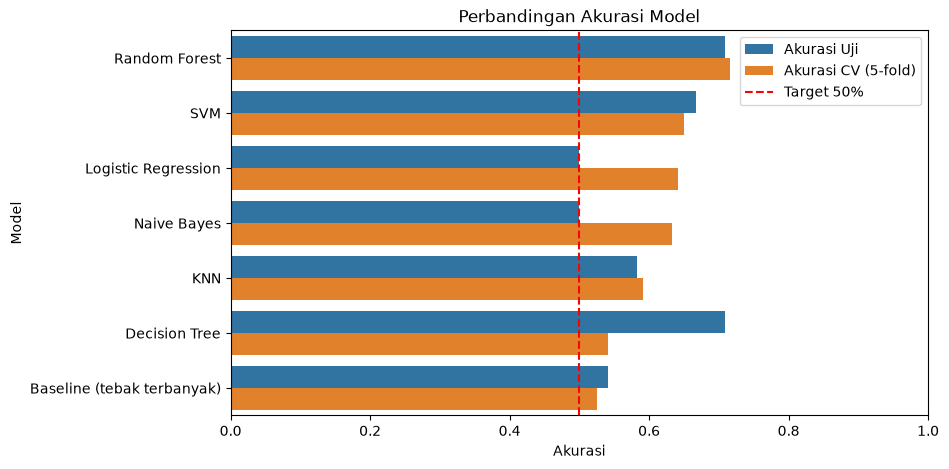

In [6]:
plt.figure(figsize=(9, 5))
data = hasil_df.melt(id_vars="Model", var_name="Jenis", value_name="Akurasi")
sns.barplot(data=data, x="Akurasi", y="Model", hue="Jenis")
plt.axvline(0.5, color="red", linestyle="--", label="Target 50%")
plt.xlim(0, 1)
plt.legend()
plt.title("Perbandingan Akurasi Model")
plt.show()

## 7. Model Terbaik
Model terbaik dipilih dari **akurasi cross-validation**, karena lebih stabil daripada akurasi pada 24 data uji.

In [7]:
tanpa_baseline = hasil_df[~hasil_df["Model"].str.startswith("Baseline")].reset_index(drop=True)
best_name = tanpa_baseline.loc[0, "Model"]
best_model = models[best_name]
best_pred = prediksi[best_name]
baseline_cv = hasil_df.loc[hasil_df["Model"].str.startswith("Baseline"), "Akurasi CV (5-fold)"].iloc[0]

print(f"Model terbaik      : {best_name}")
print(f"Akurasi CV (5-fold): {tanpa_baseline.loc[0, 'Akurasi CV (5-fold)']:.4f}")
print(f"Akurasi data uji   : {tanpa_baseline.loc[0, 'Akurasi Uji']:.4f}")
print(f"Baseline (menebak) : {baseline_cv:.4f}")
print()
print(classification_report(y_test, best_pred, target_names=["Ringan", "Berat"]))

Model terbaik      : Random Forest
Akurasi CV (5-fold): 0.7167
Akurasi data uji   : 0.7083
Baseline (menebak) : 0.5250

              precision    recall  f1-score   support

      Ringan       0.80      0.62      0.70        13
       Berat       0.64      0.82      0.72        11

    accuracy                           0.71        24
   macro avg       0.72      0.72      0.71        24
weighted avg       0.73      0.71      0.71        24



## 8. Confusion Matrix

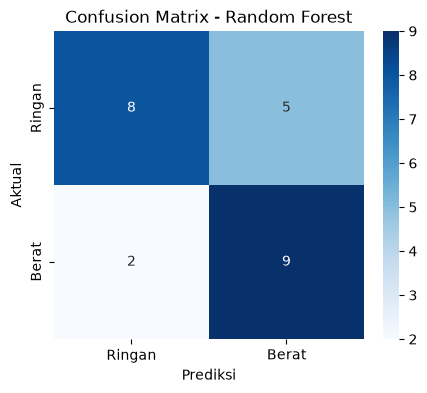

In [8]:
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Ringan", "Berat"], yticklabels=["Ringan", "Berat"])
plt.title(f"Confusion Matrix - {best_name}")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

## 9. Item Sampah Paling Berpengaruh (Permutation Importance)

   Item  Importance
 Item_8    0.058333
 Item_4    0.037500
Item_13    0.037500
Item_20    0.025000
 Item_9    0.014583


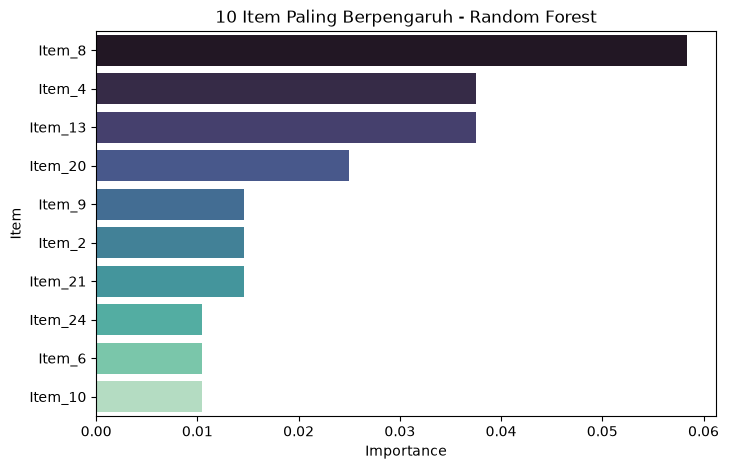

In [ ]:
perm = permutation_importance(best_model, X_test, y_test, n_repeats=20, random_state=42)
imp = pd.DataFrame({"Item": X.columns, "Importance": perm.importances_mean}) \
        .sort_values("Importance", ascending=False)

print(imp.head(5).to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(data=imp.head(10), x="Importance", y="Item", hue="Item", legend=False, palette="mako")
plt.title(f"10 Item Paling Berpengaruh - {best_name}")
plt.show()

## 10. Deployment Sederhana
Model disimpan ke file `.pkl`, dimuat lagi, lalu dipakai memprediksi beberapa sampel data uji. Muat file pickle hanya dari sumber yang dipercaya dan dengan versi library yang sama.

In [ ]:
with open("model_marine_debris.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("model_marine_debris.pkl", "rb") as f:
    model_dimuat = pickle.load(f)

label_map = {0: "Ringan", 1: "Berat"}
contoh = X_test.head(8)
tabel = pd.DataFrame({
    "Berat asli (kg)": berat.loc[contoh.index].values,
    "Kelas aktual": [label_map[v] for v in y_test.loc[contoh.index]],
    "Kelas prediksi": [label_map[v] for v in model_dimuat.predict(contoh)],
})
tabel

## 11. Monitoring
- Bandingkan prediksi dengan berat hasil timbangan asli setiap ada survei baru, lalu hitung ulang akurasi.
- Jika pola sampah berubah (musim, regulasi plastik, lokasi survei baru), lakukan *retraining* dengan data terbaru.

## 12. Kesimpulan
Isi berdasarkan output di atas:
- Model terbaik dan akurasi CV-nya, dibandingkan dengan baseline.
- Batas kelas (median berat) dan alasan memilih klasifikasi: regresi sebelumnya hanya mencapai R2 sekitar 0.09.
- Item sampah yang paling berpengaruh (lihat permutation importance).
- Keterbatasan: hanya 120 sampel, dan batas Ringan/Berat ditentukan dari median data ini, bukan standar resmi.
- Kaitan dengan SDG 14: prioritas pengangkutan sampah pesisir.